In [1]:
import skysurvey

/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/ligo/skymap/bayestar/__init__.py:34: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
snia = skysurvey.SNeIa()

In [4]:
snia.template

In [7]:
snia.template.sncosmo_model

In [8]:
snia.template.source

<SALT2Source 'salt2' version='T23' at 0x7641e8b83750>

In [9]:
snia.template_parameters

['z', 't0', 'x0', 'x1', 'c']

In [10]:
snia.get_rate(0.1)

23500.0

In [11]:
from pprint import pprint
pprint(snia.model.model)
type(snia.model.model)

{'c': {'func': <function SNeIaColor.intrinsic_and_dust at 0x7641677114e0>,
       'kwargs': {}},
 'magabs': {'func': <function SNeIaMagnitude.tripp1998 at 0x764167711640>,
            'kwargs': {'c': '@c', 'mabs': -19.3, 'sigmaint': 0.1, 'x1': '@x1'}},
 'magobs': {'func': 'magabs_to_magobs',
            'kwargs': {'magabs': '@magabs', 'z': '@z'}},
 'radec': {'as': ['ra', 'dec'],
           'func': <function random_radec at 0x764168bb8880>,
           'kwargs': {}},
 'redshift': {'as': 'z',
              'func': 'draw_redshift',
              'kwargs': {'rate': 23500.0, 'zmax': 0.2}},
 't0': {'func': <bound method Generator.uniform of Generator(PCG64) at 0x764163D60580>,
        'kwargs': {'high': 56200, 'low': 56000}},
 'x1': {'func': <function SNeIaStretch.nicolas2021 at 0x764167711590>,
        'kwargs': {}}}


dict

In [14]:
data = snia.draw(size = 10_000) #draw draws the parameters following the transient's model

In [15]:
data

,z,x1,c,t0,ra,dec,magabs,magobs
0,0.19245,0.255,0.120,56179.125633,125.974867,33.243857,-19.098648,20.834832
1,0.16915,1.000,0.012,56079.921644,350.227548,-11.073857,-19.363529,20.259799
2,0.11525,0.190,-0.015,56004.782895,73.936006,30.316285,-19.254023,19.463102
3,0.16875,-0.485,-0.071,56139.281423,36.287051,-54.316251,-19.284406,20.333260
4,0.16315,-0.270,-0.052,56113.929082,316.460963,-8.451492,-19.340053,20.196989
...,...,...,...,...,...,...,...,...
9995,0.11195,-0.440,0.394,56066.512660,211.325192,20.443287,-17.946734,20.702651
9996,0.08665,-2.035,-0.026,56067.496682,318.068148,-13.655122,-19.090445,18.966237
9997,0.10395,1.440,0.120,56134.918540,301.849806,-16.670054,-19.127770,19.349241
9998,0.14415,-0.905,0.121,56097.918023,227.534655,11.976246,-18.598119,20.644726


In [26]:
snia.data
skysurvey.SNeIa.data
help(skysurvey.SNeIa.from_draw)

Help on method from_draw in module skysurvey.target.core:

from_draw(
    size=None,
    model=None,
    template=None,
    zmax=None,
    tstart=None,
    tstop=None,
    zmin=0,
    nyears=None,
    skyarea=None,
    rate=None,
    effect=None,
    cosmology=None,
    verbose=False,
    set_amplitude=False,
    **kwargs
) class method of skysurvey.target.snia.SNeIa
    Load the instance from a random draw of targets given the model.

    kwargs may hold specific transient options like:
    - magabs for TSTransient(){self._additional_input}
    (see class.__init__).

    Parameters
    ----------
    size : int, optional
        Number of target you want to sample. If None, 1 is assumed.
        Ignored if `nyears` is given. By default None.
    model : dict, optional
        Defines how template parameters are drawn and how they are
        connected. The model will update the default `cls._MODEL` if any.
        If None, `cls._MODEL` is used as default. By default None.
    template

In [22]:
type(snia)

skysurvey.target.snia.SNeIa

In [ ]:
snia = skysurvey.SNeIa.from_draw(1, template)

In [17]:
snia.template

In [31]:
snIIn = skysurvey.TSTransient.from_draw(size=4_000, template="v19-2010al")

In [18]:
help(snia.show_lightcurve)

Help on method show_lightcurve in module skysurvey.target.core:

show_lightcurve(
    band,
    index,
    params=None,
    ax=None,
    fig=None,
    colors=None,
    phase_range=None,
    npoints=500,
    zp=25,
    zpsys='ab',
    format_time=True,
    t0_format='mjd',
    in_mag=False,
    invert_mag=True,
    **kwargs
) method of skysurvey.target.snia.SNeIa instance
    Show the lightcurve.

    Parameters
    ----------
    band : str
        The band to show.
    index : int
        The index of the target.
    params : dict, optional
        Parameters to pass to `get_target_template`. By default None.
    ax : matplotlib.axes.Axes, optional
        The axes to show the lightcurve on. By default None.
    fig : matplotlib.figure.Figure, optional
        The figure to show the lightcurve on. By default None.
    colors : list, optional
        The colors to use for the lightcurve. By default None.
    phase_range : list, optional
        The phase range to show. By default None.

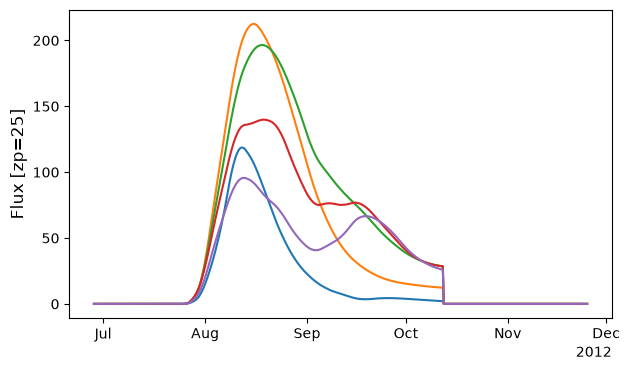

In [60]:
# colors = ["tab:green", "tab:red"]
_ = snia.show_lightcurve(("lsstu", "lsstg", "lsstr", "lssti", "lsstz"), index = 50, colors = None, phase_range = (-50, 100))

In [12]:
help(snia.show_lightcurve)

Help on method show_lightcurve in module skysurvey.target.core:

show_lightcurve(
    band,
    index,
    params=None,
    ax=None,
    fig=None,
    colors=None,
    phase_range=None,
    npoints=500,
    zp=25,
    zpsys='ab',
    format_time=True,
    t0_format='mjd',
    in_mag=False,
    invert_mag=True,
    **kwargs
) method of skysurvey.target.snia.SNeIa instance
    Show the lightcurve.

    Parameters
    ----------
    band : str
        The band to show.
    index : int
        The index of the target.
    params : dict, optional
        Parameters to pass to `get_target_template`. By default None.
    ax : matplotlib.axes.Axes, optional
        The axes to show the lightcurve on. By default None.
    fig : matplotlib.figure.Figure, optional
        The figure to show the lightcurve on. By default None.
    colors : list, optional
        The colors to use for the lightcurve. By default None.
    phase_range : list, optional
        The phase range to show. By default None.

## TO DO 24 Jul 2026
Remember: use random population to generate the event!
ref docs: https://skysurvey.readthedocs.io/en/latest/howto/load_lsst.html

### Load LSST filepath
can take a while to load

In [44]:
opsim_path = "baseline_v5.1.0_10yrs.db" # provide fullpath
lsst = skysurvey.LSST.from_opsim(opsim_path)

DatabaseError: Execution failed on sql 'SELECT fieldRA, fieldDec, observationStartMJD, visitExposureTime, filter, skyBrightness, fiveSigmaDepth, night, numExposures, observationId FROM OBSERVATIONS ': no such table: OBSERVATIONS